# AI 211 - Machine Exercise 1
## Problem 2: Classifying Breast Tumors

**Instructor:** Prof. Karl Ezra Pilario, Ph.D.  
**Due Date:** 11:59 PM, September 15, 2026  
**Semester:** 1st Semester, AY 2026-2027  

**Authors:** Adriane Jone A. Abunda | Ejcurl B. Delarmente

### Problem
Reference: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29 

Download the Wisconsin Breast Cancer dataset. The dataset contains 569 instances of breast tumors 
with 30 attributes. The goal is make a classifer for the tumor status. 

- a. [20 pts] Split the samples into 70% Training and 30% Testing at random. Make sure to use 
“stratify=y” in the test_train_split function. Build a pipeline using the Standard scaler and logistic 
regression. Use the default penalty settings of Logistic Regression. After fitting the data, what is 
the model’s training and testing accuracy? Which features are most important? 
- b. [20 pts] From your answer in item (a), generate a confusion matrix, then calculate the other 
metrics: F1-score, Precision, Recall, and False alarm rate. Finally, plot the ROC curve and report 
the AUC. For this item, make a result for both the training and testing data, separately. 

Based on your results for this Problem, what insights did you gain?

In [33]:
# Import libraries and pacakges
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

RANDOM_SEED = 23

In [3]:
# Load the dataset
columns = [
    "ID", "Diagnosis", "radius1", "texture1", "perimeter1", "area1", "smoothness1", "compactness1", "concavity1",
    "concave_points1", "symmetry1", "fractal_dimension1", "radius2", "texture2", "perimeter2", "area2", "smoothness2",
    "compactness2", "concavity2", "concave_points2", "symmetry2", "fractal_dimension2", "radius3", "texture3",
    "perimeter3", "area3", "smoothness3", "compactness3", "concavity3", "concave_points3", "symmetry3", "fractal_dimension3"
]
data = pd.read_csv("wdbc.data", header=None, names=columns)
data.head(5)

,ID,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# EDA
## Dataset Preview
Size, Dtypes, missing values, duplicates, etc.

In [4]:
# Drop the ID column as it has no predictive value
data = data.drop("ID", axis=1)  

In [5]:
data.shape

(569, 31)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Diagnosis           569 non-null    str    
 1   radius1             569 non-null    float64
 2   texture1            569 non-null    float64
 3   perimeter1          569 non-null    float64
 4   area1               569 non-null    float64
 5   smoothness1         569 non-null    float64
 6   compactness1        569 non-null    float64
 7   concavity1          569 non-null    float64
 8   concave_points1     569 non-null    float64
 9   symmetry1           569 non-null    float64
 10  fractal_dimension1  569 non-null    float64
 11  radius2             569 non-null    float64
 12  texture2            569 non-null    float64
 13  perimeter2          569 non-null    float64
 14  area2               569 non-null    float64
 15  smoothness2         569 non-null    float64
 16  compactness2       

In [7]:
data.duplicated().sum()

np.int64(0)

## Statistical Overview

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Diagnosis class distribution

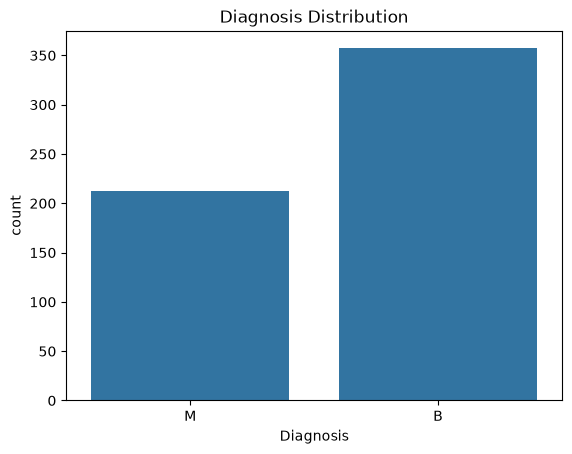

In [9]:
data['Diagnosis'].value_counts()
sns.countplot(data=data, x='Diagnosis')
plt.title('Diagnosis Distribution')
plt.show()

## Machine Learning Model Development

Feature, Model Selection, Preprocessing, and Training

In [11]:
# Feature selection and preprocessing
data['Diagnosis'] = data['Diagnosis'].map({'M': 1, 'B': 0})

X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

print(f"Predictors columns: {X.columns}")
print(f"Target columns: {y.unique()}")

Predictors columns: Index(['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3'],
      dtype='str')
Target columns: [1 0]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=23, stratify=y)

model = Pipeline([("num", StandardScaler()),
                  ("classifier", LogisticRegression(random_state=RANDOM_SEED))])

In [13]:
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)
print(f"Logistic Regression train accuracy: {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Logistic Regression test accuracy: {accuracy_score(y_test, y_pred_test):.3f}")

Logistic Regression train accuracy: 0.985
Logistic Regression test accuracy: 0.977


In [14]:
coefficients = model.named_steps['classifier'].coef_[0]

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': coefficients
})

feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

print(feature_importance)

               feature  coefficient  abs_coefficient
10             radius2     1.275717         1.275717
7      concave_points1     1.109114         1.109114
21            texture3     1.052689         1.052689
20             radius3     0.934605         0.934605
13               area2     0.916537         0.916537
24         smoothness3     0.902115         0.902115
27     concave_points3     0.871420         0.871420
23               area3     0.841525         0.841525
26          concavity3     0.790825         0.790825
22          perimeter3     0.664088         0.664088
19  fractal_dimension2    -0.657750         0.657750
6           concavity1     0.655266         0.655266
5         compactness1    -0.649020         0.649020
12          perimeter2     0.648246         0.648246
28           symmetry3     0.616544         0.616544
15        compactness2    -0.552980         0.552980
3                area1     0.443332         0.443332
29  fractal_dimension3     0.401326         0.

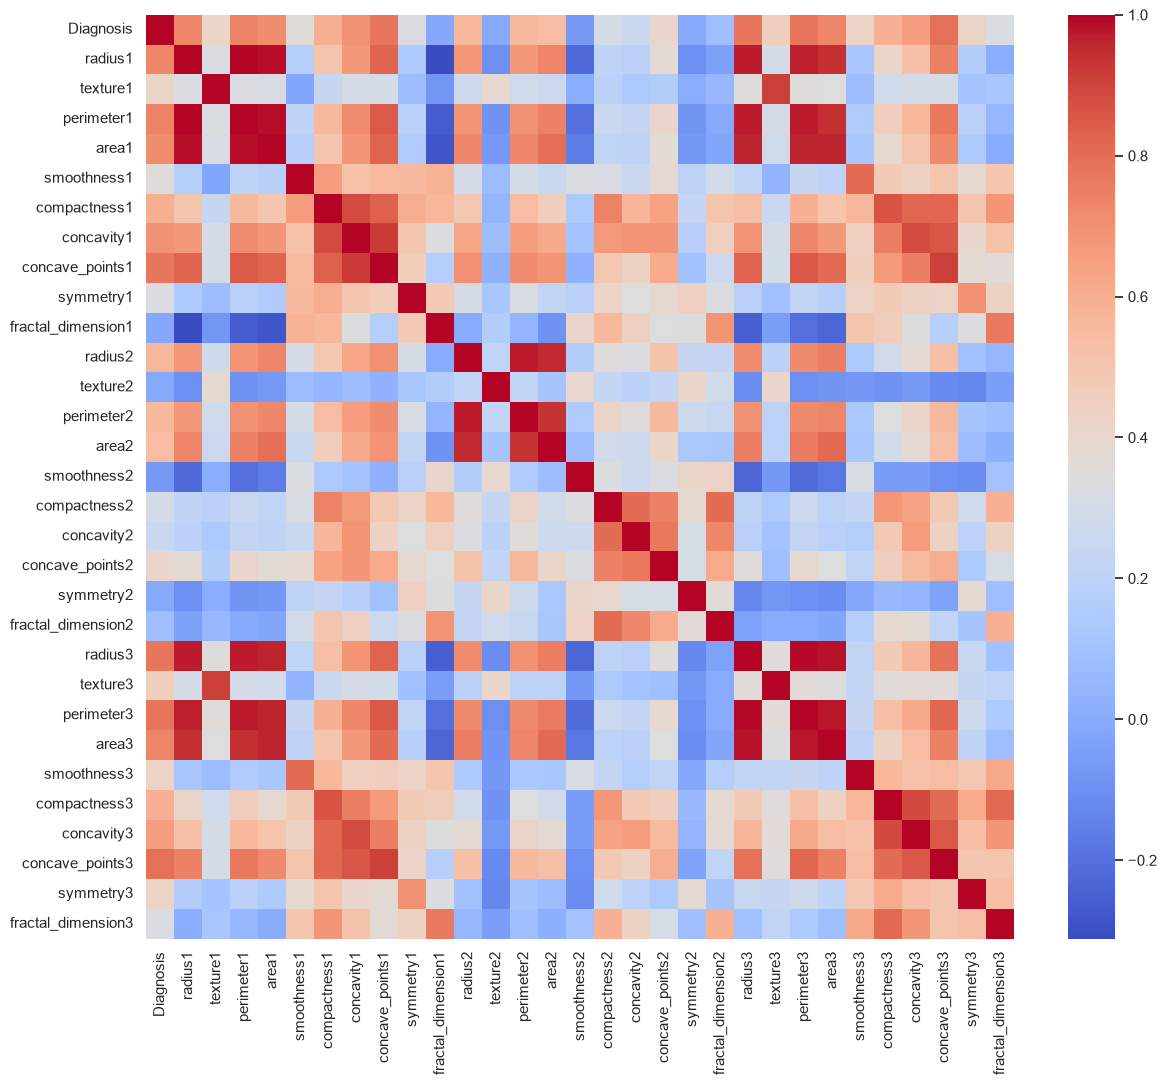

In [27]:
# Correlation of features with Diagnosis

plt.figure(figsize=(14, 12))
sns.set(style="whitegrid")
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [19]:
corr_with_target = corr['Diagnosis'].drop('Diagnosis').sort_values(ascending=False)
print(corr_with_target)

concave_points3       0.793566
perimeter3            0.782914
concave_points1       0.776614
radius3               0.776454
perimeter1            0.742636
area3                 0.733825
radius1               0.730029
area1                 0.708984
concavity1            0.696360
concavity3            0.659610
compactness1          0.596534
compactness3          0.590998
radius2               0.567134
perimeter2            0.556141
area2                 0.548236
texture3              0.456903
smoothness3           0.421465
symmetry3             0.416294
texture1              0.415185
concave_points2       0.408042
smoothness1           0.358560
symmetry1             0.330499
fractal_dimension3    0.323872
compactness2          0.292999
concavity2            0.253730
fractal_dimension2    0.077972
symmetry2            -0.006522
texture2             -0.008303
fractal_dimension1   -0.012838
smoothness2          -0.067016
Name: Diagnosis, dtype: float64


## Part (a): Summary of Results
Model: Logistic Regression (default penalty) with Standard Scaler preprocessing, fitted on a 70/30 stratified train-test split (random_state = 23).

Performance:
- Training Accuracy: 0.985
- Testing Accuracy: 0.977

The small gap between training and testing accuracy suggests the model generalizes well, with no strong evidence of overfitting.

Most Important Features:

Based on Logistic Regression coefficient magnitudes (after scaling):
1. radius2 (standard error)
2. concave_points1 (mean)
3. texture3 (worst)
4. radius3 (worst)
5. area2 (standard error)

Based on correlation with the target (Diagnosis):
1. concave_points3 (worst)
2. perimeter3 (worst)
3. concave_points1 (mean)
4. radius3 (worst)
5. perimeter1 (mean)

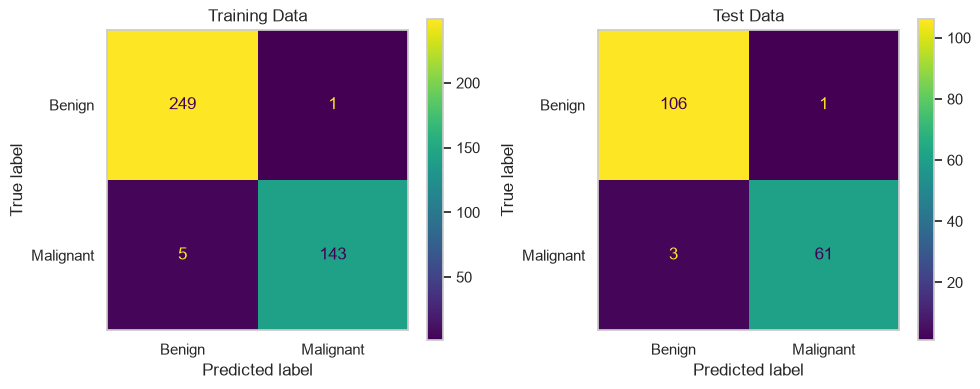

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cfm_train = confusion_matrix(y_train, y_pred_train)
cm_display_train = ConfusionMatrixDisplay(confusion_matrix=cfm_train, display_labels=["Benign", "Malignant"])
cm_display_train.plot(ax=axes[0])
axes[0].set_title('Training Data')

cfm_test = confusion_matrix(y_test, y_pred_test)
cm_display_test = ConfusionMatrixDisplay(confusion_matrix=cfm_test, display_labels=["Benign", "Malignant"])
cm_display_test.plot(ax=axes[1])
axes[1].set_title('Test Data')
axes[0].grid(False)
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [28]:
def false_alarm(y_true, y_pred):
    """Calculate the false alarm rate (FPR) for a binary classification problem."""
    cm = confusion_matrix(y_true, y_pred)
    FP = cm[0][1]
    TN = cm[0][0]
    return FP / (FP + TN)

print(f"Logistic Regression train F1-score: {f1_score(y_train, y_pred_train):.3f}")
print(f"Logistic Regression test F1-score: {f1_score(y_test, y_pred_test):.3f}")

print(f"Logistic Regression train Precision: {precision_score(y_train, y_pred_train):.3f}")
print(f"Logistic Regression test Precision: {precision_score(y_test, y_pred_test):.3f}")

print(f"Logistic Regression train Recall: {recall_score(y_train, y_pred_train):.3f}")
print(f"Logistic Regression test Recall: {recall_score(y_test, y_pred_test):.3f}")

print(f"Logistic Regression train False Alarm Rate: {false_alarm(y_train, y_pred_train):.3f}")
print(f"Logistic Regression test False Alarm Rate: {false_alarm(y_test, y_pred_test):.3f}")

Logistic Regression train F1-score: 0.979
Logistic Regression test F1-score: 0.968
Logistic Regression train Precision: 0.993
Logistic Regression test Precision: 0.984
Logistic Regression train Recall: 0.966
Logistic Regression test Recall: 0.953
Logistic Regression train False Alarm Rate: 0.004
Logistic Regression test False Alarm Rate: 0.009


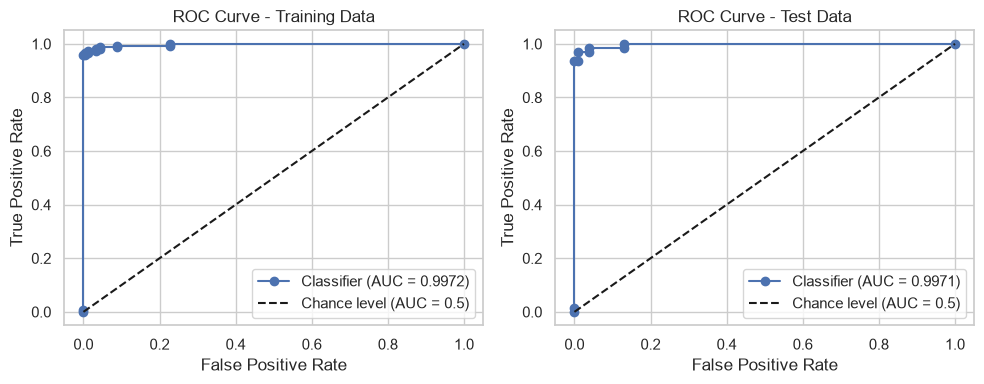

In [34]:
# ROC Curve and AUC

proba_train = model.predict_proba(X_train)[:, 1]
proba_test = model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, proba_train)
fpr_test, tpr_test, _ = roc_curve(y_test, proba_test)

auc_train = roc_auc_score(y_train, proba_train)
auc_test = roc_auc_score(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(fpr_train, tpr_train, 'b-o', label=f'Classifier (AUC = {auc_train:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Training Data')
axes[0].legend()

axes[1].plot(fpr_test, tpr_test, 'b-o', label=f'Classifier (AUC = {auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Chance level (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Data')
axes[1].legend()

plt.tight_layout()
plt.show()

## Part (b): Summary of Results

Confusion Matrix:

| | Predicted Benign | Predicted Malignant |
|---|---|---|
| Actual Benign (Train) | 249 | 1 |
| Actual Malignant (Train) | 5 | 143 |

| | Predicted Benign | Predicted Malignant |
|---|---|---|
| Actual Benign (Test) | 106 | 1 |
| Actual Malignant (Test) | 3 | 61 |

Classification Metrics (Positive class = Malignant):

| Metric | Training | Testing |
|---|---|---|
| F1-score | 0.979 | 0.968 |
| Precision | 0.993 | 0.984 |
| Recall | 0.966 | 0.953 |
| False Alarm Rate (FPR) | 0.004 | 0.009 |

ROC-AUC:
- Training AUC: 0.9972
- Testing AUC: 0.9971

## Insights

- Feature scaling was essential. EDA revealed that the 30 features span vastly different ranges (e.g., `area` in the hundreds vs. `smoothness` below 1). Since Logistic Regression relies on distance and gradient-based optimization, StandardScaler ensured no feature dominated purely due to its raw magnitude, and made the resulting coefficients directly comparable to each other.

- Correlation and model-based feature importance told different stories. Simple correlation with the target ranked size-related "worst" and "mean" features (`concave_points`, `perimeter`, `radius`) as most important. However, the Logistic Regression coefficients placed more weight on `radius2` and `texture3`. This divergence is likely due to multicollinearity, since radius, perimeter, and area are highly correlated with one another, the model distributes predictive weight across them instead of concentrating it on one dominant feature. This shows that correlation alone can be a misleading for feature importance in a multivariate model.

- The model achieved excellent, well-generalized performance. Training and testing accuracy (98.5% and 97.7%), F1-scores (0.98 and 0.97), and AUC (0.9972 and 0.9971) were all close in value, indicating the model did not overfit despite using all 30 features with default regularization settings.

- Precision exceeded Recall in both sets, meaning the model rarely misclassifies benign tumors as malignant (very low false alarm rate), but still misses a small number of actual malignant cases (5 in training, 3 in testing). In a medical diagnostic context, this false negative is the more consequential error, since a missed cancer diagnosis carries greater risk than a false alarm that a follow-up test would likely correct. This suggests that if this model were deployed, prioritizing Recall may be more clinically appropriate than optimizing for overall accuracy alone.

- No missing values, duplicates, or invalid entries were found in the dataset, and several near-zero minimum values (e.g., in `concavity`) reflect genuine biological readings rather than data errors, reinforcing the importance of domain context when interpreting EDA results, rather than assuming all extreme values are noise to be removed.